All pipeline functions are present in `src/preprocessing.py` and are imported
above. This notebook is for validating the design decisions visually ,
each comparison below is what justified locking in the pipeline.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

sys.path.append("src/")
from data_utils import save_figure
from preprocessing import (
    crop_black_border, pad_to_square, resize_image, apply_clahe,
    normalize_for_efficientnet, full_pipeline_preprocess,
    build_paths_labels, build_augmentation, make_dataset,
    compute_class_weights, TARGET_SIZE
)

root_dir = "archive"

train_df = pd.read_csv(
    os.path.join(root_dir, "train_clean.csv")
)

valid_df = pd.read_csv(
    os.path.join(root_dir, "valid.csv")
)

test_df = pd.read_csv(
    os.path.join(root_dir, "test.csv")
)

train_images_dir = os.path.join(
    root_dir,
    "train_images",
    "train_images"
)

valid_images_dir = os.path.join(
    root_dir,
    "val_images",
    "val_images"
)

test_images_dir = os.path.join(
    root_dir,
    "test_images",
    "test_images"
)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

Train: (2886, 2)
Valid: (366, 2)
Test : (366, 2)


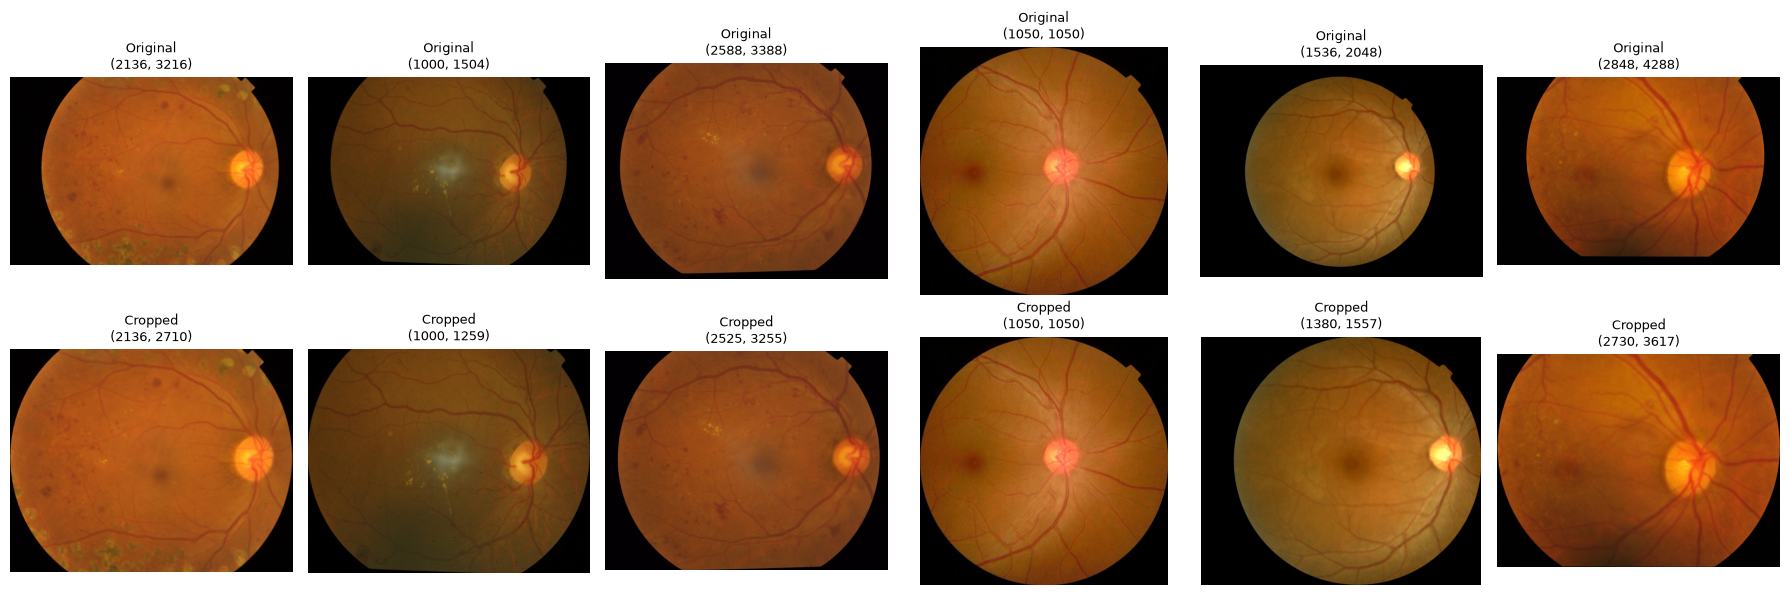

In [2]:
## Step 1 — Crop black border

def compare_crop(df, images_dir, n_samples=6, random_state=42):
    sample_df = df.sample(n_samples, random_state=random_state)
    
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples*3, 6))
    
    for col, img_id in enumerate(sample_df['id_code']):
        img_path = os.path.join(images_dir, img_id + ".png")
        img = cv2.imread(img_path)
        cropped = crop_black_border(img)
        
        axes[0, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, col].set_title(f"Original\n{img.shape[:2]}", fontsize=9)
        axes[0, col].axis('off')
        
        axes[1, col].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        axes[1, col].set_title(f"Cropped\n{cropped.shape[:2]}", fontsize=9)
        axes[1, col].axis('off')
    
    plt.tight_layout()
    plt.show()

compare_crop(train_df, train_images_dir, n_samples=6)

the four corners of that rectangle will always fall outside the circle, A tiny fraction of total pixels,Pure black (zero information), model trained on it just learns to ignore that region since it's a fixed, uninformative part of every image.

real complexity (need to detect circle center + radius, apply a mask, handle mask edge artifacts) for a marginal gain : not needed as the model will absorb it for free.

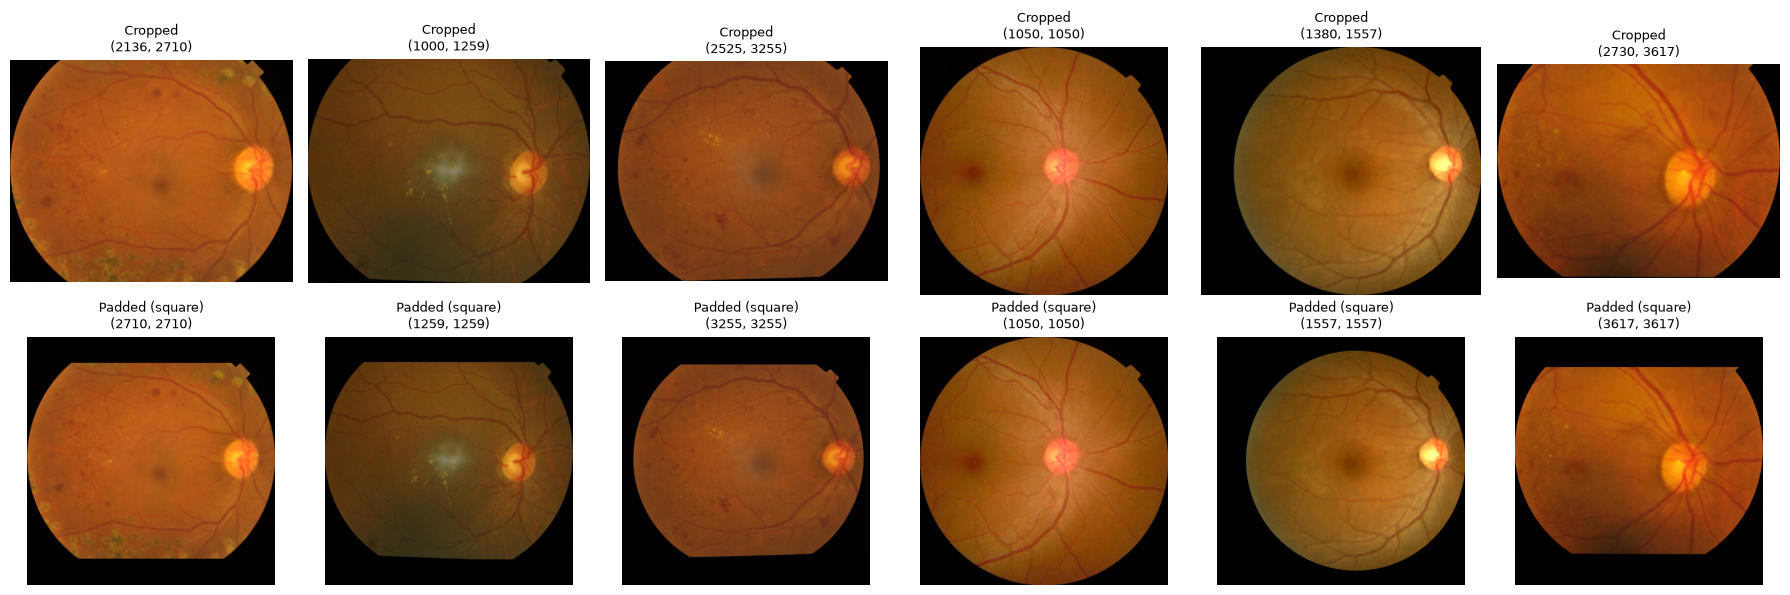

In [3]:
## Step 2 — Pad to square (preserve aspect ratio)

def compare_crop_and_pad(df, images_dir, n_samples=6, random_state=42):
    sample_df = df.sample(n_samples, random_state=random_state)
    
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples*3, 6))
    
    for col, img_id in enumerate(sample_df['id_code']):
        img_path = os.path.join(images_dir, img_id + ".png")
        img = cv2.imread(img_path)
        cropped = crop_black_border(img, threshold=9)
        padded = pad_to_square(cropped)
        
        axes[0, col].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        axes[0, col].set_title(f"Cropped\n{cropped.shape[:2]}", fontsize=9)
        axes[0, col].axis('off')
        
        axes[1, col].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
        axes[1, col].set_title(f"Padded (square)\n{padded.shape[:2]}", fontsize=9)
        axes[1, col].axis('off')
    
    plt.tight_layout()
    plt.show()

compare_crop_and_pad(train_df, train_images_dir, n_samples=6)

We use INTER_AREA as if works by averaging the pixel area and produces faithful results for downsizing instead of opencv's default interpolation which can introduce aliasing artifacts while shrinking.

Figure saved to: ./outputs/figures/04_full_pipeline_before_after.png


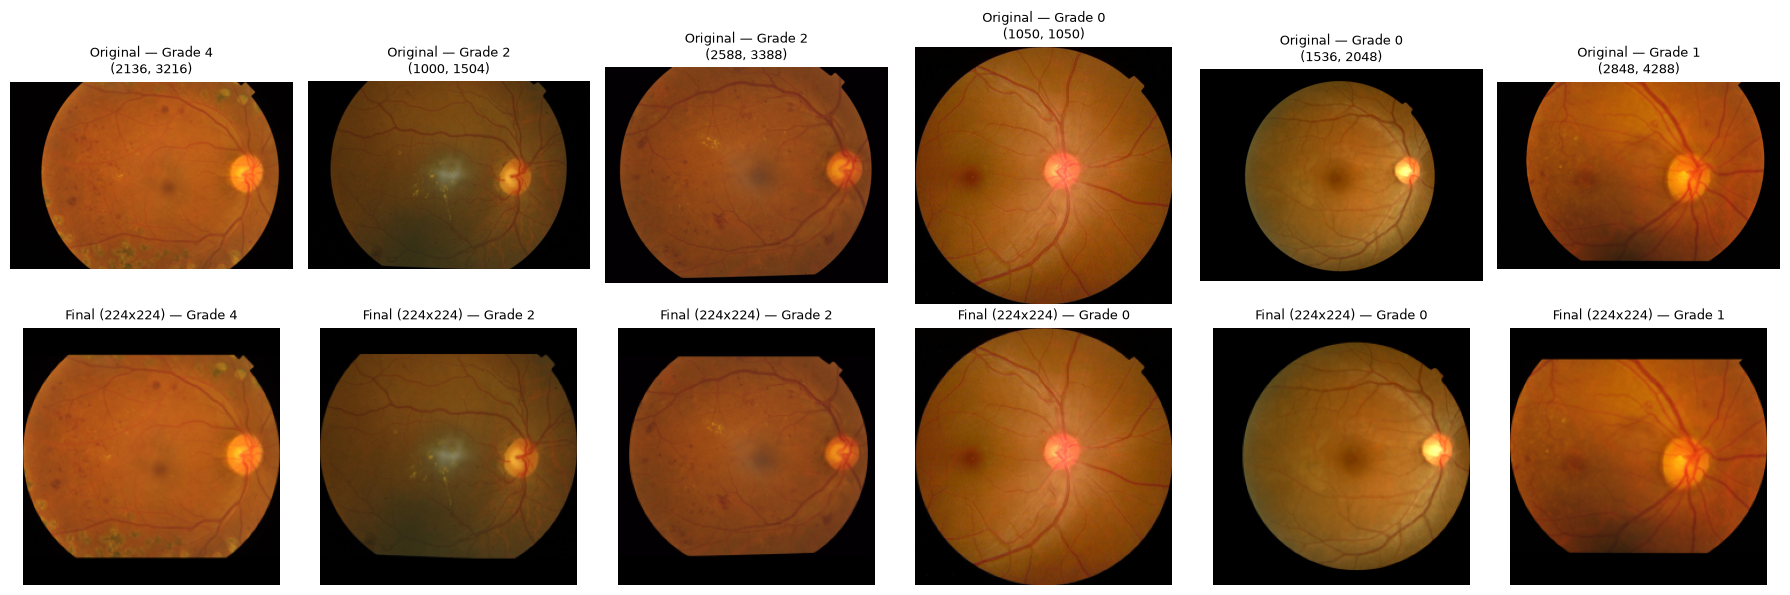

In [4]:
## Step 3 — Resize

#Comparision 
def compare_full_pipeline(df, images_dir, n_samples=6, target_size=224, random_state=42, save_path=None):
    sample_df = df.sample(n_samples, random_state=random_state)
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples*3, 6))

    for col, row in enumerate(sample_df.itertuples()):
        img_id, grade = row.id_code, row.diagnosis
        img_path = os.path.join(images_dir, img_id + ".png")
        img = cv2.imread(img_path)
        cropped = crop_black_border(img)
        padded = pad_to_square(cropped)
        processed = resize_image(padded, target_size=target_size)

        axes[0, col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, col].set_title(f"Original — Grade {grade}\n{img.shape[:2]}", fontsize=9)
        axes[0, col].axis('off')

        axes[1, col].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
        axes[1, col].set_title(f"Final ({target_size}x{target_size}) — Grade {grade}", fontsize=9)
        axes[1, col].axis('off')

    plt.tight_layout()
    save_figure(fig, save_path)
    plt.show()

fig = compare_full_pipeline(train_df, train_images_dir, n_samples=6, target_size=224,
                             save_path="./outputs/figures/04_full_pipeline_before_after.png")

No stretching of retina or any distortion visible , the scattered dark dots (hemorrhages/microaneurysms) are still clearly distinguishable at 224×224, Borders are handled correctly . 

limitation: some images of retina are non-circular aperture , camera behavior.

locked pipeline till here , 
testing a hypothesis: CLAHE for adaptive contrasting 

Figure saved to: ./outputs/figures/05_clahe_before_after.png


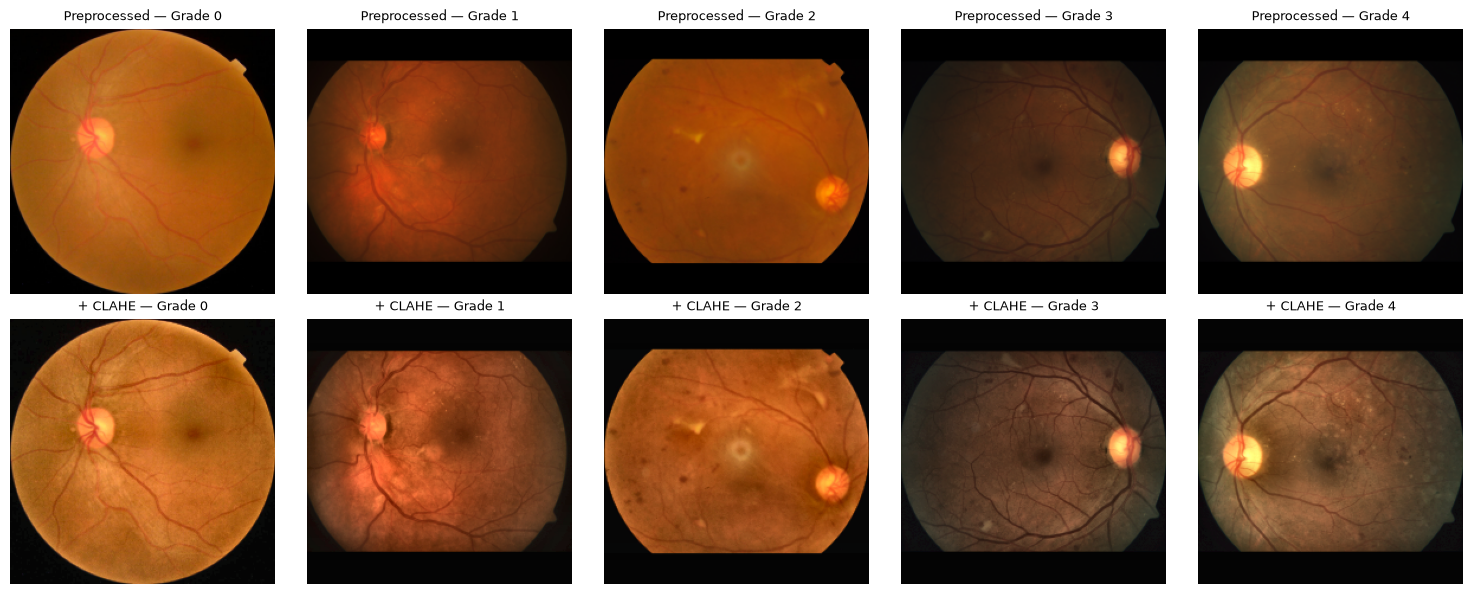

In [5]:
def compare_clahe(df, images_dir, n_samples=6, target_size=224, random_state=42, save_path=None):
    samples = []
    for grade, group in df.groupby('diagnosis'):
        samples.append(group.sample(1, random_state=random_state))
    sample_df = pd.concat(samples).reset_index(drop=True)

    fig, axes = plt.subplots(2, len(sample_df), figsize=(len(sample_df)*3, 6))

    for col, row in sample_df.iterrows():
        img_path = os.path.join(images_dir, row['id_code'] + ".png")
        img = cv2.imread(img_path)
        cropped = crop_black_border(img)
        padded = pad_to_square(cropped)
        processed = resize_image(padded, target_size=target_size)
        enhanced = apply_clahe(processed)

        axes[0, col].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
        axes[0, col].set_title(f"Preprocessed — Grade {row['diagnosis']}", fontsize=9)
        axes[0, col].axis('off')

        axes[1, col].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
        axes[1, col].set_title(f"+ CLAHE — Grade {row['diagnosis']}", fontsize=9)
        axes[1, col].axis('off')

    plt.tight_layout()
    save_figure(fig, save_path)
    plt.show()

fig = compare_clahe(train_df, train_images_dir, n_samples=6, target_size=224,
                     save_path="./outputs/figures/05_clahe_before_after.png")

Positive Hypothesis Testing 
Observation: 
No Noise produces in the background region , CLAHE operates on real content and not the padding , the blood vessels and structure details are enhanced in the regions it matters . 

In [6]:
## Step 5 — Normalization for EfficientNet

test_pixel = np.array([[[128, 64, 200]]], dtype='float32')
print("Before:", test_pixel)
print("After :", normalize_for_efficientnet(test_pixel))

Before: [[[128.  64. 200.]]]
After : [[[128.  64. 200.]]]


Efficientnet has a rescaling layer inbuild in its model itself therefore preprocess_input() step has no-op.

FULL PREPROCESS PIPELINE 

crop -> pad -> resize -> CLAHE -> BGR->RGB -> normalize, wrapped for `tf.data` via `tf.py_function`, then cached -> (shuffled) -> batched -> (augmented) -> prefetched. Augmentation (flip + mild rotation only, train-only) and dataset assembly.

added class weights to make rare classes loss to be counted more than the common clases 

In [7]:
## Step 6 — Full `tf.data` pipeline

train_paths, train_labels = build_paths_labels(train_df, train_images_dir)
valid_paths, valid_labels = build_paths_labels(valid_df, valid_images_dir)
test_paths, test_labels   = build_paths_labels(test_df, test_images_dir)

train_ds = make_dataset(train_paths, train_labels, training=True, batch_size=16)
valid_ds = make_dataset(valid_paths, valid_labels, training=False, batch_size=16)
test_ds  = make_dataset(test_paths, test_labels, training=False, batch_size=16)

'''class_weight_dict = compute_class_weights(train_labels)
print("Class weights:", class_weight_dict)'''

I0000 00:00:1787826200.371396   19113 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


'class_weight_dict = compute_class_weights(train_labels)\nprint("Class weights:", class_weight_dict)'

In [8]:
## Sanity check
TARGET_SIZE=224

for imgs, labels in train_ds.take(1):
    print("Batch image shape:", imgs.shape)
    print("Batch label shape:", labels.shape)
    print("Pixel value range:", imgs.numpy().min(), "to", imgs.numpy().max())
    print("Sample labels:", labels.numpy())

I0000 00:00:1787826250.626759   19720 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 287 of 2886
I0000 00:00:1787826260.630486   19720 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 597 of 2886
I0000 00:00:1787826270.891475   19720 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 911 of 2886
I0000 00:00:1787826291.022569   19720 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 1528 of 2886
I0000 00:00:1787826310.658868   19720 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2207 of 2886
I0000 00:00:1787826320.959607   19720 shuffle_dataset_op.cc:453] ShuffleDatasetV3:3: Filling up shuffle buffer (this may take a while): 2504 of 2886
I0000 00:00:1787826334.241161   19720 shuffle_dataset_op.cc:483] Shuffle buffer filled.


Batch image shape: (16, 224, 224, 3)
Batch label shape: (16,)
Pixel value range: 0.0 to 255.0
Sample labels: [2 0 2 0 2 0 2 2 3 2 0 2 0 3 2 2]
